In [3]:
from typing import Union, Tuple, Optional, Set, List
import os
import pandas as pd


import matplotlib.pyplot as plt
from pathlib import Path

In [4]:
def plot_gini_vs_alpha(
    datasets: List[str],
    fairness_metric: str = "gini@10",
    base_dir: Union[str, Path] = "./hyper-test",
    show: bool = True,
    save_path: Optional[str] = None,
) -> Tuple[plt.Figure, tuple[plt.Axes, plt.Axes, plt.Axes]]:
    """
    Make three side-by-side plots with the chosen fairness metric on Y.

    Sources:
      1) ./hyper-test/{dataset}/SASRec_amplify_{dataset}-results.csv  -> x: alpha_unpop
      2) ./hyper-test/{dataset}/SASRec_dampen_{dataset}-results.csv   -> x: alpha_pop
      3) ./hyper-test/{dataset}/SASRec_N_{dataset}-results.csv        -> x: n

    Rules:
      - Drop rows where the x column is negative.
      - Each dataset uses a distinct marker and points are connected in x order.
      - Legend label equals the dataset name.
    """
    base_dir = Path(base_dir)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)
    ax_amp, ax_dmp, ax_n = axes

    markers = ['o', 's', '^', 'v', 'D', 'P', 'X', '*', 'h', '>', '<', 'p', 'H', '8']

    def plot_one(ax: plt.Axes, file_stub: str, x_col: str, title: str):
        any_plotted = False
        for i, dataset in enumerate(datasets):
            csv_path = base_dir / dataset / f"{file_stub}_{dataset}-results.csv"
            if not csv_path.exists():
                print(f"[skip] Not found: {csv_path}")
                continue

            df = pd.read_csv(csv_path)
            df.columns = df.columns.str.strip()

            if x_col not in df.columns or fairness_metric not in df.columns:
                print(f"[skip] Missing '{x_col}' or '{fairness_metric}' in {csv_path}")
                continue

            sub = df[df[x_col] >= 0].copy()
            if sub.empty:
                print(f"[skip] No non-negative {x_col} rows for {dataset}")
                continue

            sub = sub.sort_values(x_col)
            ax.plot(
                sub[x_col].to_numpy(),
                sub[fairness_metric].to_numpy(),
                marker=markers[i % len(markers)],
                linestyle='-',
                label=dataset,
            )
            any_plotted = True

        ax.set_xlabel(x_col)
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        return any_plotted

    p1 = plot_one(ax_amp, "SASRec_amplify", "alpha_unpop", "Amplify")
    p2 = plot_one(ax_dmp, "SASRec_dampen", "alpha_pop",   "Dampen")
    p3 = plot_one(ax_n,   "SASRec_N",       "n",           "N-mode")

    ax_amp.set_ylabel(fairness_metric)

    # One combined legend
    handles, labels = [], []
    for ax in axes:
        h, l = ax.get_legend_handles_labels()
        if h:
            handles, labels = h, l
            break
    if handles:
        fig.legend(handles, labels, title="Dataset", loc="upper center",
                   ncol=min(4, len(labels)), bbox_to_anchor=(0.5, 1.06))

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
    if show:
        plt.show()

    return fig, (ax_amp, ax_dmp, ax_n)

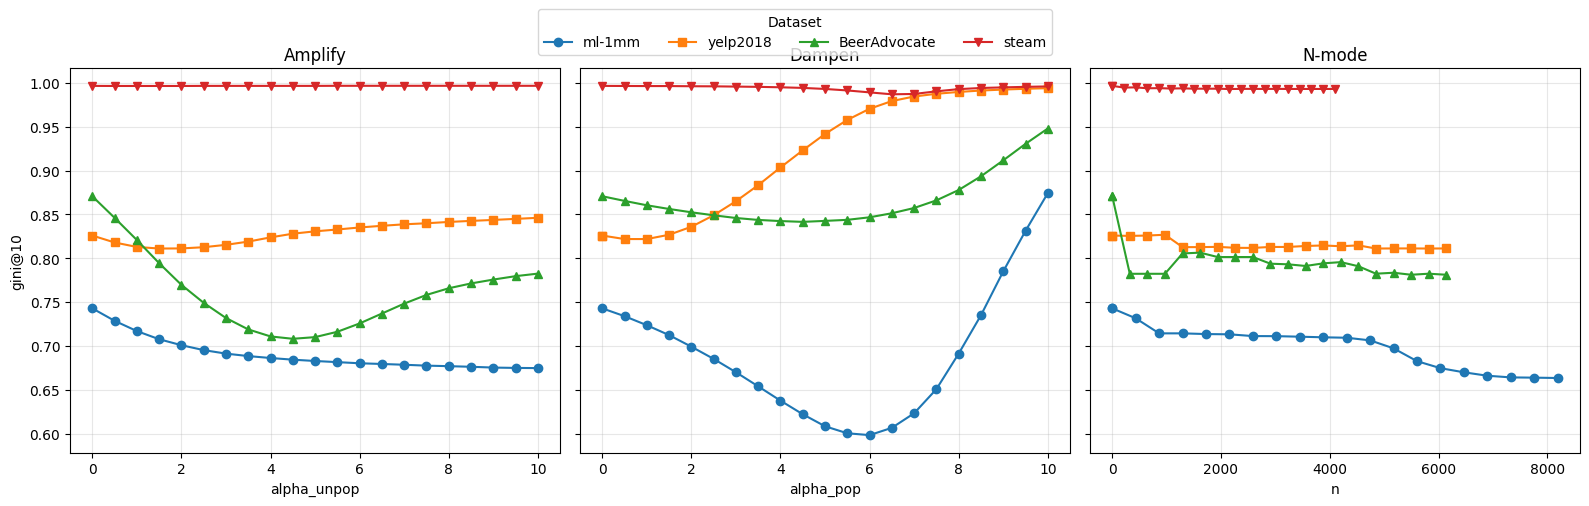

(<Figure size 1600x480 with 3 Axes>,
 (<Axes: title={'center': 'Amplify'}, xlabel='alpha_unpop', ylabel='gini@10'>,
  <Axes: title={'center': 'Dampen'}, xlabel='alpha_pop'>,
  <Axes: title={'center': 'N-mode'}, xlabel='n'>))

In [6]:
plot_gini_vs_alpha(datasets=["ml-1mm", "yelp2018", "BeerAdvocate", "steam"], fairness_metric="gini@10")


In [5]:
def fix_ndcg_columns(dataset: str) -> None:
    """
    Adjust all result CSVs in ./dataset/{dataset}/results-final:
    • ndcg@10tail   ←  ndcg - ndcg@head
    • drop column 'ndcg@mid'
    • save the amended files in a new sibling folder
      ./dataset/{dataset}/results-final/new  (same filenames)

    Parameters
    ----------
    dataset : str
        The dataset folder name (e.g. "msmarco", "trec23", …).
    """
    # Resolve paths
    base_dir = Path(f"./hyper-test/{dataset}").resolve()
    new_dir  = base_dir / "new"
    new_dir.mkdir(parents=True, exist_ok=True)

    # Process every *.csv in the source directory (non-recursive)
    for csv_path in base_dir.glob("*.csv"):
        df = pd.read_csv(csv_path)

        # Re-compute ndcg@10tail and drop ndcg@mid if present
        if {"ndcg", "ndcghead@10"}.issubset(df.columns):
            df["ndcgtail@10"] = df["ndcg"] - df["ndcghead@10"]
        else:
            raise KeyError(
                f"Required columns missing in {csv_path.name}: "
                "expected 'ndcg' and 'ndcg@head'."
            )

        if "ndcgmid@10" in df.columns:
            df = df.drop(columns="ndcgmid@10")

        # Write out with identical filename into the /new folder
        df.to_csv(new_dir / csv_path.name, index=False)

    print(f"✔ All CSVs processed; output written to: {new_dir}")

In [10]:
fix_ndcg_columns("yelp2018")

✔ All CSVs processed; output written to: C:\Users\tukaz\OneDrive\Desktop\thesis\PopSteer2.0\notebooks\interpretability\hyper-test\yelp2018\new
